In [1]:
## 2진 분류 => cat & dog
## 부족한 수량 증강(회전/플립)
## 리사이징 크기 결정 => 리사이징 진행
## 이미지 리드(2차원) -> reshape(1차원) -> 리스트(str) => CSV 파일로 저장
## 0~155 => 0.0 ~ 1.0 

## 파일명 : 라벨 (cat(1), dog(1))  / 폴더명 : cat / dog

[1] 모듈 로딩 및 설정 <hr>

In [2]:
## 모듈 로딩
import sys, os
sys.path.append("C:\KDT9\K09_OPENCV") # 사용자 모듈이 들어있는 폴더 주소

## 사용자 모듈 로딩
import utils

## 시스템 모듈 로딩
import cv2

In [3]:
## 데이터 관련 설정
DATA_DIR  = '../Data/catdog'          # 수집 데이터 존재 폴더
SAVE_DIR  = '../Data/project00'       # 전처리 데이터 존재 폴더
TRAIN_DIR = '../Data/project00/Train' # 학습용 데이터 저장 폴더
TEST_DIR  = '../Data/project00/Test'  # 검증용 데이터 저장 폴더

## 이미지 확장자 종류
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}

print('DATA_DIR:', DATA_DIR)
print('SAVE_DIR:', SAVE_DIR)

DATA_DIR: ../Data/catdog
SAVE_DIR: ../Data/project00


[2] 수집된 이미지 데이터 체크 <hr>

In [4]:
## 폴더 안에 이미지 파일명 읽기
filenameList = os.listdir(DATA_DIR)
print('총 파일 개수 : ', len(filenameList))
print('5개 샘플 파일명 : ', filenameList[:5])

## 파일 경로 리스트
filepath = [os.path.join(DATA_DIR, fname) for fname in filenameList]
print('총 파일 개수 : ', len(filepath))
print('파일 경로 : ', filepath[:5])

총 파일 개수 :  343
5개 샘플 파일명 :  ['cat(1).jpg', 'cat(10).jpg', 'cat(100).jpg', 'cat(101).jpg', 'cat(102).jpg']
총 파일 개수 :  343
파일 경로 :  ['../Data/catdog\\cat(1).jpg', '../Data/catdog\\cat(10).jpg', '../Data/catdog\\cat(100).jpg', '../Data/catdog\\cat(101).jpg', '../Data/catdog\\cat(102).jpg']


[3] 수집 데이터 분석을 통한 이미지 리사이징 <hr>

In [5]:
# ## 원본 이미지 로딩 후 resize ==> 저장하기
# for imgfile in filepath :

#     # 이미지 데이터 로딩
#     img = cv2.imread(imgfile)
#     print(imgfile, img)
#     if img is None : 
#         print(f"{imgfile} : 이미지 데이터 로딩 실패")
#     else :
#         # 리사이징 이미지 저장 경로
#         filepathname = f'{SAVE_DIR}/{os.path.basename(imgfile)}'

#         simg = cv2.resi

In [6]:
## 수집 데이터 분석
target_size = utils.analyze_and_recommend(DATA_DIR)
print(f'target_size = {target_size}')

총 이미지 수 : 343
짧은 변  → min: 46, median: 183.0, max: 5464
긴 변    → min: 47, median: 300.0, max: 8192

추천 리사이즈 크기: 160 × 160
target_size = 160


In [7]:
## 리사이징 후 저장
utils.resize_and_save_center_crop(DATA_DIR, SAVE_DIR, target_size)

총 343장의 이미지를 160×160 (비율 유지 + 중앙 크롭)으로 저장 완료 → ../Data/project00


[4] 학습 이미지 데이터 분류 <hr>

In [8]:
## 라벨, 데이터 분류
def get_label_from_name(fname:str) :
    name, ext = os.path.splitext(fname)
    if ext.lower() not in IMG_EXTS :
        return None  # 이미지 확장자 아니면 제외
    
    n = name.lower()
    if "cat" in n :
        return "cat"
    elif "dog" in n :
        return "dog"
    else :
        return None

## 샘플 확인
for f in filenameList[:10] :
    label = get_label_from_name(f)
    print(f'{f} => 라벨 : {label}')

cat(1).jpg => 라벨 : cat
cat(10).jpg => 라벨 : cat
cat(100).jpg => 라벨 : cat
cat(101).jpg => 라벨 : cat
cat(102).jpg => 라벨 : cat
cat(103).jpg => 라벨 : cat
cat(104).jpg => 라벨 : cat
cat(105).jpg => 라벨 : cat
cat(106).jpg => 라벨 : cat
cat(107).jpg => 라벨 : cat


라벨링 유효 파일 : 343
샘플 5개 : [{'path': '../Data/catdog\\cat(1).jpg', 'file': 'cat(1).jpg', 'label': 'cat'}, {'path': '../Data/catdog\\cat(10).jpg', 'file': 'cat(10).jpg', 'label': 'cat'}, {'path': '../Data/catdog\\cat(100).jpg', 'file': 'cat(100).jpg', 'label': 'cat'}, {'path': '../Data/catdog\\cat(101).jpg', 'file': 'cat(101).jpg', 'label': 'cat'}, {'path': '../Data/catdog\\cat(102).jpg', 'file': 'cat(102).jpg', 'label': 'cat'}]
label
cat    279
dog     64
Name: count, dtype: int64
label
cat    0.813411
dog    0.186589
Name: proportion, dtype: float64


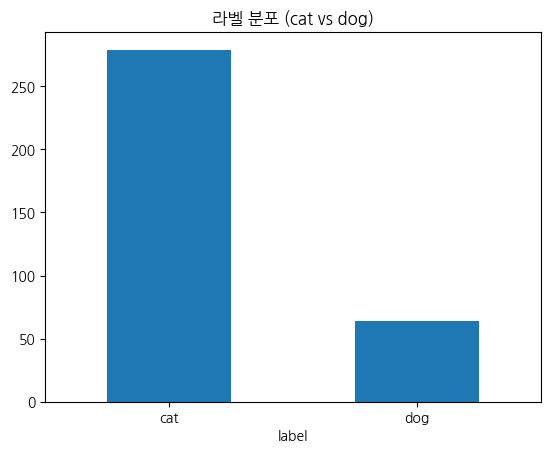

In [9]:
## 전체 파일 라벨링
import pandas as pd
import matplotlib.pyplot as plt

records = []
for f in filenameList :
    label = get_label_from_name(f)
    if label is None : 
        continue
    records.append({
        'path': os.path.join(DATA_DIR, f),
        'file' : f,
        'label' : label
    })

print('라벨링 유효 파일 :', len(records))
print('샘플 5개 :', records[:5])

## 라벨 분포
df = pd.DataFrame(records)
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True))

df['label'].value_counts().plot(kind='bar', rot=0)
plt.title('라벨 분포 (cat vs dog)')
plt.show()

In [10]:
## 학습용/검증용 데이터 분할
from sklearn.model_selection import train_test_split

## X : 경로, y : 라벨
X = df['path'].values
y = df['label'].values\

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    stratify=y,
                                                    random_state=42)

print('Train 개수 :', len(X_train))
print('Test  개수 :', len(X_test))

print('Train 샘플 3개 :', X_train[:3], y_train[:3])
print('Test  샘플 3개:', X_test[:3], y_test[:3])

Train 개수 : 274
Test  개수 : 69
Train 샘플 3개 : ['../Data/catdog\\cat(149).jpg' '../Data/catdog\\cat(71).jpg'
 '../Data/catdog\\cat(108).jpg'] ['cat' 'cat' 'cat']
Test  샘플 3개: ['../Data/catdog\\cat(152).jpg' '../Data/catdog\\dog(50).jpg'
 '../Data/catdog\\dog(45).jpg'] ['cat' 'dog' 'dog']


In [11]:
## 폴더 구조
def safe_mkdir(path):
    os.makedirs(path, exist_ok=True)

## Train, Test 각각 cat/dog 디렉토리 생성
for root in [TRAIN_DIR, TEST_DIR] :
    safe_mkdir(os.path.join(root, 'cat'))
    safe_mkdir(os.path.join(root, 'dog'))

In [12]:
## 학습용/검증용 파일로 저장
## records 파일 DataFrame
df = pd.DataFrame(records) # colums : ['path','file', 'label']

## Train/Test 분할 결과 CSV 생성
train_df = pd.DataFrame({'path': X_train, 'label': y_train})
test_df  = pd.DataFrame({'path': X_test, 'label': y_test})

## Train/Test 분류
train_df['split'] = 'train'
test_df['split']  = 'test'

## 저장 경로
os.makedirs(SAVE_DIR, exist_ok=True)

## CSV 파일 저장
train_csv = os.path.join(SAVE_DIR, 'train.csv')
test_csv = os.path.join(SAVE_DIR, 'test.csv')

## 인코딩
train_df.to_csv(train_csv, index=False, encoding='utf-8')
test_df.to_csv(test_csv, index=False, encoding='utf-8')

print('csv 저장 완료:', train_csv, test_csv)
print(train_df.head())
print(test_df.head())

csv 저장 완료: ../Data/project00\train.csv ../Data/project00\test.csv
                          path label  split
0  ../Data/catdog\cat(149).jpg   cat  train
1   ../Data/catdog\cat(71).jpg   cat  train
2  ../Data/catdog\cat(108).jpg   cat  train
3  ../Data/catdog\cat(150).jpg   cat  train
4   ../Data/catdog\dog(28).jpg   dog  train
                          path label split
0  ../Data/catdog\cat(152).jpg   cat  test
1   ../Data/catdog\dog(50).jpg   dog  test
2   ../Data/catdog\dog(45).jpg   dog  test
3  ../Data/catdog\cat(233).jpg   cat  test
4  ../Data/catdog\cat(191).jpg   cat  test


In [13]:
## csv 파일 저장 확인
missing_train = [p for p in train_df['path'] if not os.path.exists(p)]
missing_test  = [p for p in test_df['path']  if not os.path.exists(p)]

print("Train 누락 파일 수:", len(missing_train))
print("Test 누락 파일 수 :", len(missing_test))

Train 누락 파일 수: 0
Test 누락 파일 수 : 0


In [14]:
## CSV 파일 로드 및 라벨 인코딩
import numpy as np

## CSV 파일 읽기
train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

## 라벨 인코딩
label_to_idx = {'cat':0, 'dog':1}
train_df['label_idx'] = train_df['label'].map(label_to_idx)
test_df['label_idx'] = test_df['label'].map(label_to_idx)

print(train_df.head())
print(test_df.head())

                          path label  split  label_idx
0  ../Data/catdog\cat(149).jpg   cat  train          0
1   ../Data/catdog\cat(71).jpg   cat  train          0
2  ../Data/catdog\cat(108).jpg   cat  train          0
3  ../Data/catdog\cat(150).jpg   cat  train          0
4   ../Data/catdog\dog(28).jpg   dog  train          1
                          path label split  label_idx
0  ../Data/catdog\cat(152).jpg   cat  test          0
1   ../Data/catdog\dog(50).jpg   dog  test          1
2   ../Data/catdog\dog(45).jpg   dog  test          1
3  ../Data/catdog\cat(233).jpg   cat  test          0
4  ../Data/catdog\cat(191).jpg   cat  test          0


In [ ]:
## 이미지 벡터 변환
IMG_H, IMG_W = 160, 160

def load_images(paths):
    data = []
    for p in paths:
        img = cv2.imread(p)                    # 이미지 읽기
        img = cv2.resize(img, (IMG_W, IMG_H))  # 혹시 크기 달라도 맞추기
        img = img.flatten() / 255.0            # 1차원 벡터 + 정규화
        data.append(img)
    return np.array(data)

# X, y 만들기
X_train = load_images(train_df['path'])
y_train = (train_df['label'] == 'dog').astype(int)  # cat=0, dog=1

X_test  = load_images(test_df['path'])
y_test  = (test_df['label'] == 'dog').astype(int)

[5] 학습 평가 <hr>

In [16]:
## 로지스틱 회귀분석 모델 학습
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

print("Train 정확도:", clf.score(X_train, y_train))
print("Test 정확도 :", clf.score(X_test, y_test))

Train 정확도: 1.0
Test 정확도 : 0.8115942028985508


In [17]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['cat','dog']))
print("혼동행렬:\n", confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

         cat       0.86      0.91      0.89        56
         dog       0.50      0.38      0.43        13

    accuracy                           0.81        69
   macro avg       0.68      0.65      0.66        69
weighted avg       0.80      0.81      0.80        69

혼동행렬:
 [[51  5]
 [ 8  5]]


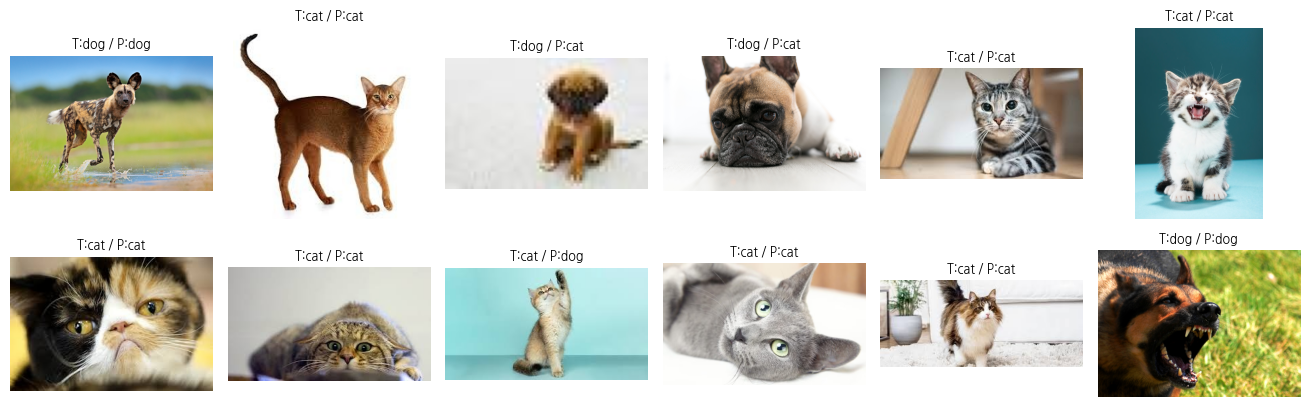

In [18]:
import numpy as np, random, cv2, matplotlib.pyplot as plt, os

# 경로/라벨 준비
# paths = test_df['path'].values
# y_test = (test_df['label'] == 'dog').astype(int).values
# y_pred = clf.predict(X_test)

name = {0:'cat', 1:'dog'}

def show_random_samples(paths, true, pred, k=12, seed=42, cols=6):
    random.seed(seed)
    idxs = random.sample(range(len(paths)), min(k, len(paths)))
    rows = int(np.ceil(len(idxs)/cols))
    plt.figure(figsize=(2.2*cols, 2.2*rows))
    for i, ix in enumerate(idxs, 1):
        img = cv2.imread(paths[ix])
        if img is None:
            img = np.zeros((160,160,3), np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax = plt.subplot(rows, cols, i)
        ax.imshow(img); ax.axis('off')
        ax.set_title(f"T:{name[true[ix]]} / P:{name[pred[ix]]}", fontsize=9)
        color = 'green' if true[ix]==pred[ix] else 'red'
        for s in ax.spines.values():
            s.set_edgecolor(color); s.set_linewidth(2)
    plt.tight_layout(); plt.show()

# 확인
paths = test_df['path'].values
show_random_samples(paths, y_test, y_pred, k=12)


오분류 개수: 13


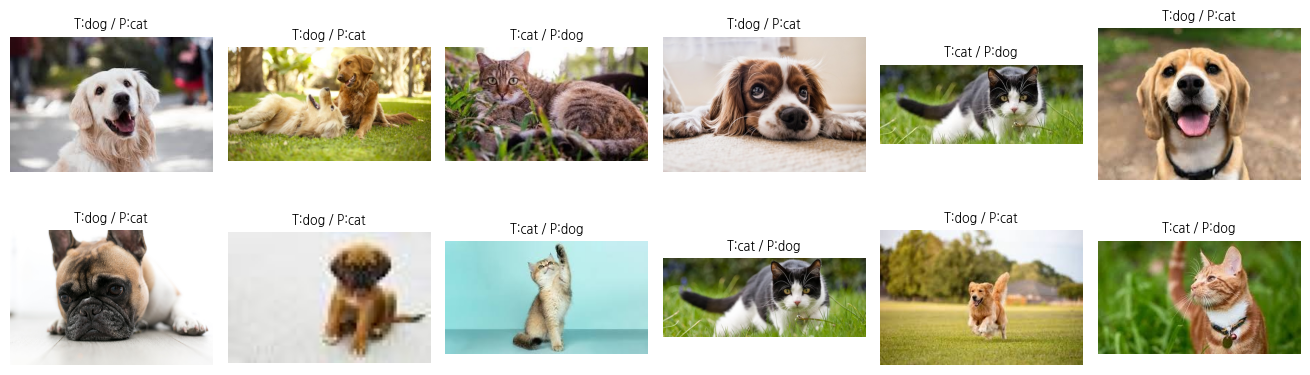

In [19]:
def show_misclassified(paths, true, pred, k=12, cols=6):
    wrong = np.where(true != pred)[0]
    print("오분류 개수:", len(wrong))
    if len(wrong) == 0:
        return
    pick = wrong[:min(k, len(wrong))]
    rows = int(np.ceil(len(pick)/cols))
    plt.figure(figsize=(2.2*cols, 2.2*rows))
    for i, ix in enumerate(pick, 1):
        img = cv2.imread(paths[ix])
        if img is None:
            img = np.zeros((160,160,3), np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax = plt.subplot(rows, cols, i)
        ax.imshow(img); ax.axis('off')
        ax.set_title(f"T:{name[true[ix]]} / P:{name[pred[ix]]}", fontsize=9)
        for s in ax.spines.values():  # 오분류니까 빨간 테두리
            s.set_edgecolor('red'); s.set_linewidth(2)
    plt.tight_layout(); plt.show()

# 확인
show_misclassified(paths, y_test, y_pred, k=12)
